# LightGBM Classifier - March 18 Legacy Review Schema

Legacy-compatible notebook for the largest March 18 review DB. It keeps the old `event_class` labels as the default training target and also derives current taxonomy columns from those legacy labels so the previous review work remains usable.

In [1]:
from pathlib import Path
import sys

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)

root_candidates = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next(
    (
        p
        for p in root_candidates
        if (p / "malca").is_dir()
        and (p / "output" / "runs" / "runs_march18_bundle_all" / "review" / "review.db").exists()
    ),
    Path.cwd(),
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from malca.meta_analysis.ml.review_lightgbm import (
    LEGACY_MARCH18_TARGET_COLUMNS,
    TrainingConfig,
    label_audit,
    load_legacy_march18_training_table,
    train_review_models,
)

RUN_DIR = REPO_ROOT / "output" / "runs" / "runs_march18_bundle_all"
REVIEW_DB = RUN_DIR / "review" / "review.db"
FLAT_LIGHTCURVE_DIR = RUN_DIR / "bundle_assets" / "lightcurves"
OUTPUT_DIR = REPO_ROOT / "output" / "ml" / "march18_legacy_schema"
LIGHTCURVE_FEATURE_CACHE = OUTPUT_DIR / "lightcurve_features.parquet"

TARGET_COLUMNS = list(LEGACY_MARCH18_TARGET_COLUMNS)
# To train on lossy taxonomy labels derived from old event_class values, use:
# TARGET_COLUMNS = ["event_class", "morphology_primary", "physical_primary"]

INCLUDE_LIGHTCURVE_FEATURES = True
DERIVE_TAXONOMY_FROM_EVENT_CLASS = True
MAX_LIGHTCURVES = None

CONFIG = TrainingConfig(
    random_state=42,
    test_size=0.2,
    cv_folds=5,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    n_jobs=1,
)


## Load Review Rows And Light-Curve Features

In [2]:
table = load_legacy_march18_training_table(
    REVIEW_DB,
    flat_lightcurve_dir=FLAT_LIGHTCURVE_DIR,
    include_lightcurve_features=INCLUDE_LIGHTCURVE_FEATURES,
    lightcurve_feature_cache=LIGHTCURVE_FEATURE_CACHE,
    only_reviewed=True,
    derive_taxonomy_from_event_class=DERIVE_TAXONOMY_FROM_EVENT_CLASS,
    max_lightcurves=MAX_LIGHTCURVES,
)

print(f"Loaded {len(table):,} reviewed rows and {len(table.columns):,} columns")
print(f"Review DB: {REVIEW_DB}")
print(f"Flat light-curve dir: {FLAT_LIGHTCURVE_DIR}")
display(table.head())


Loaded 1,368 reviewed rows and 486 columns
Review DB: /home/calder/code/malca/output/runs/runs_march18_bundle_all/review/review.db
Flat light-curve dir: /home/calder/code/malca/output/runs/runs_march18_bundle_all/bundle_assets/lightcurves


,candidate_id,source_path,asas_sn_id,lc_path,failed_any,periodic_flag,catalog_match,catalog_source,period_sources,period_n_sources,period_consensus_days,period_consensus_agree,period_conflict_flag,period_consensus_support,period_primary_source,period_source_periods,period_ogle_match,period_ogle_days,period_ogle_class,period_ogle_sep_arcsec,high_ruwe_flag,periodicity_score,lsp_bootstrap_sig,lsp_power,lsp_period,lsp_is_alias,lsp_is_significant,phase_plot_ready,phase_period_days,phase_source,phase_quality_score,dip_significant,dip_best_morph,dip_best_log_bf,dip_best_delta_bic,dip_best_width_param,dip_symmetry_score,dip_best_amp,dip_best_t0,dip_best_alpha,dip_best_tau,dip_bayes_factor,dip_best_p,dip_best_mag_event,dip_trigger_max,dip_max_event_prob,dip_trigger_threshold,dip_count,dip_run_count,dip_max_run_points,dip_max_run_duration,dip_max_run_sum,dip_max_run_max,dip_max_run_cameras,dip_max_log_bf_local,jump_significant,jump_best_morph,jump_best_log_bf,jump_best_delta_bic,jump_best_width_param,jump_best_amp,jump_best_t0,jump_best_alpha,jump_best_tau,jump_bayes_factor,jump_best_p,jump_best_mag_event,jump_trigger_max,jump_max_event_prob,jump_trigger_threshold,jump_count,jump_run_count,jump_max_run_points,jump_max_run_duration,jump_max_run_sum,jump_max_run_max,jump_max_run_cameras,jump_max_log_bf_local,dip_is_single_event,dip_inter_event_spacing_median,...,ltv_stoch_gp_drw_tau,payload_json,imported_at,microlens_match,microlens_catalog,microlens_name,microlens_alt_name,microlens_te_days,microlens_sep_arcsec,pdm_period,pdm_theta,pdm_snr,pdm_bootstrap_sig,pdm_is_significant,ce_period,ce_entropy,ce_snr,ce_bootstrap_sig,ce_is_significant,periodicity_bootstrap_sig,periodicity_is_significant,pm_total,high_pm_flag,stats_camera_loo_corr_min,stats_camera_loo_corr_median,stats_camera_loo_rms_max,pre_periodicity_label,pre_periodic_flag,pre_periodicity_selected_period,pre_periodicity_method,interest_score,event_class,review_pass,notes,status,reviewer,updated_at,workflow_status,disposition,morphology_primary,morphology_secondary,morphology_polarity,morphology_recurrence,baseline_behavior,physical_family,physical_subclass,classification_confidence,priority_tags_json,evidence_flags_json,model_tags_json,duplicate_of,known_object_id,known_object_source,taxonomy_version,legacy_review_json,physical_primary,physical_secondary,legacy_schema_source,schema_mode,lc_path_lc,resolved_lc_path,lc_file_exists,lc_n_points,lc_n_good,lc_n_cameras,lc_n_bands,lc_time_span_days,lc_mag_median,lc_mag_std,lc_mag_mad,lc_mag_iqr,lc_mag_p05,lc_mag_p95,lc_mag_p95_minus_p05,lc_error_median,lc_g_n_points,lc_v_n_points,lc_g_mag_median,lc_v_mag_median,lc_v_minus_g_median
0,103079849011,/home/calder/code/malca/output/runs/runs_march...,103079849011,/home/calder/code/malca/output/runs/runs_march...,0,0,0,,,0.0,NaN,0,0,NaN,,,0,None,,None,0,NaN,NaN,None,NaN,0,0,0,None,,None,1,gaussian,None,137.063579,13.496557,-0.136303,0.318144,9806.460993,NaN,None,1409.304049,0.954455,13.288209,1.000000,1.000000,1.0,9.0,1.0,9.0,20.95306,9.0,1.0,2.0,269.132812,1,paczynski,None,86.455178,19.035145,-1.593717,9838.395685,None,NaN,1373.484785,0.090991,12.939683,1.000000,1.000000,1.0,7.0,1.0,7.0,10.97665,7.0,1.0,2.0,295.750674,1,NaN,...,None,"{""candidate_id"": ""103079849011"", ""path"": ""/dat...",2026-03-19T04:16:46.489987+00:00,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,4,unknown_interesting,2,,reviewed,calder,2026-03-20T20:04:21.499047+00:00,reviewed,keep,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,"{""baseline_behavior"": null, ""candidate_id"": ""1...",None,None,march18,legacy_march18,/home/calder/code/malca/output/runs/runs_march...,/home/calder/code/malca/output/runs/runs_march...,True,990,990,5,2,4046.85580,13.054109,0.106799,0.072110,0.142336,12.876349,13.234550,0.358201,0.01,810,180,13.055219,13.047317,-0.007902
1,111669286812,/home/calder/code/malca/output/runs/runs_mar

## Label Audit

In [3]:
audits = label_audit(table, TARGET_COLUMNS + ["morphology_primary", "physical_primary"])
for target, counts in audits.items():
    print(f"\n{target}")
    display(counts.rename("n").to_frame())



event_class


,n
event_class,
unknown_interesting,776
instrumental,404
other,96
ltv,36
microlensing,34
dipper,19
flare,3



morphology_primary


,n
morphology_primary,
artifact_or_bad_photometry,404
brightening_event,37
long_term_trend,36
dimming_event,19



physical_primary


,n
physical_primary,
false_positive_or_contaminant,404
microlensing,34
flare_star_or_magnetically_active_star,3


## Label Distribution Plots

These make the class imbalance visible. The model can score well on weighted metrics while still being weak on rare labels such as `dipper` or `flare`, so always read these alongside macro-F1 and per-class recall.

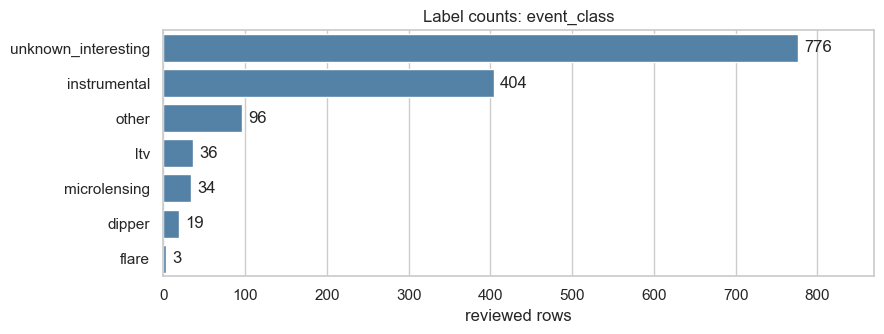

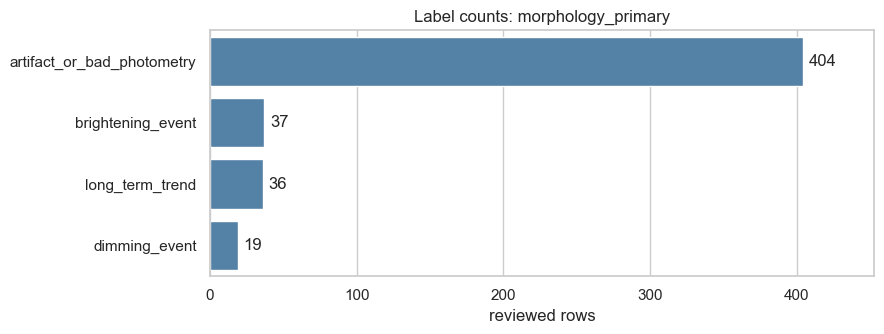

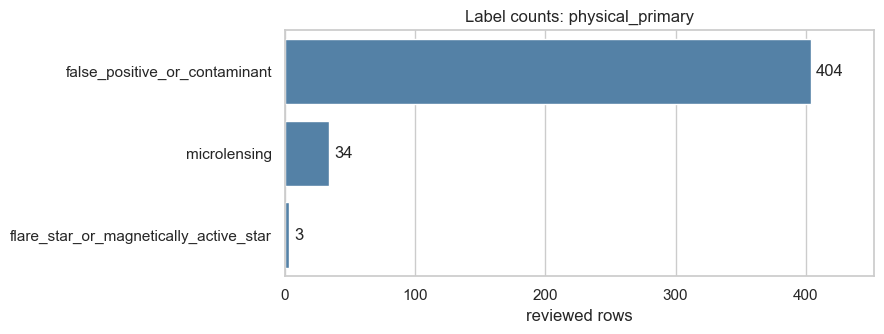

In [4]:
for target, counts in audits.items():
    if counts.empty:
        continue
    plot_df = counts.rename_axis(target).reset_index(name="n")
    plot_df[target] = plot_df[target].astype(str)
    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.45 * len(plot_df))))
    sns.barplot(data=plot_df, y=target, x="n", ax=ax, color="steelblue")
    ax.set_title(f"Label counts: {target}")
    ax.set_xlabel("reviewed rows")
    ax.set_ylabel("")
    for patch in ax.patches:
        width = patch.get_width()
        ax.text(width + max(plot_df["n"].max() * 0.01, 0.5), patch.get_y() + patch.get_height() / 2, f"{int(width):,}", va="center")
    ax.set_xlim(0, plot_df["n"].max() * 1.12)
    fig.tight_layout()
    plt.show()


## Train, Holdout-Test, And Cross-Validate

In [5]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
results = train_review_models(
    table,
    TARGET_COLUMNS,
    output_dir=OUTPUT_DIR,
    config=CONFIG,
)

for target, result in results.items():
    print(f"\n{target}: {result.n_rows:,} rows, {result.n_features:,} features")
    print("classes:", result.class_counts)
    print("holdout:", {k: v for k, v in result.holdout_metrics.items() if k != "classification_report"})
    if not result.cv_metrics.empty:
        display(result.cv_metrics)



event_class: 1,368 rows, 292 features
classes: {'dipper': 19, 'flare': 3, 'instrumental': 404, 'ltv': 36, 'microlensing': 34, 'other': 96, 'unknown_interesting': 776}
holdout: {'fold': 'holdout', 'n_eval': 274, 'accuracy': 0.8065693430656934, 'macro_f1': 0.40825899945816735, 'weighted_f1': 0.7892550477315482}


,fold,n_eval,accuracy,macro_f1,weighted_f1
0,1,456,0.853070,0.485151,0.844105
1,2,456,0.839912,0.493967,0.833702
2,3,456,0.833333,0.442979,0.815913


## Model Metric Plots

The CV plot shows fold-to-fold stability. The holdout heatmap shows which classes are actually being recovered; this is more informative than overall accuracy when the dominant class is `unknown_interesting`.

### event_class

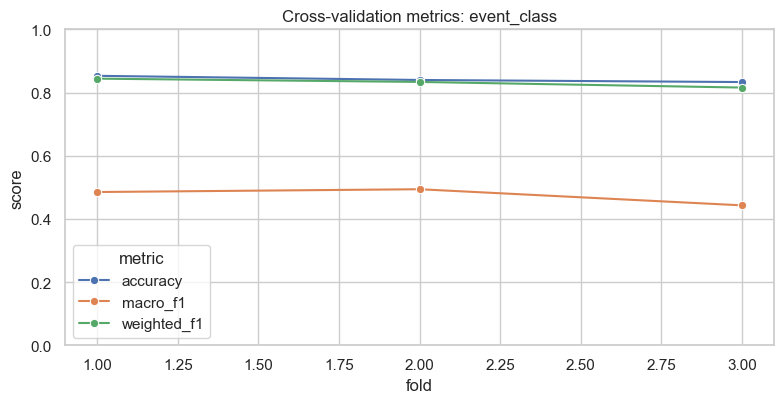

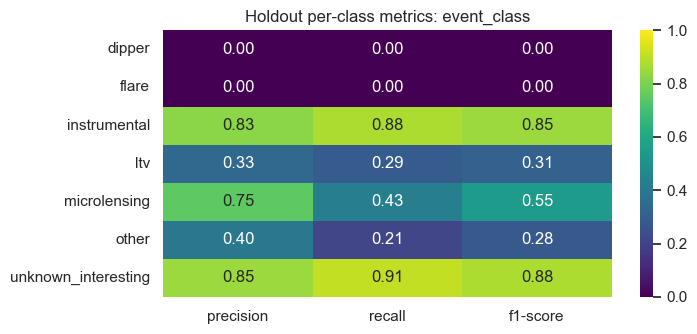

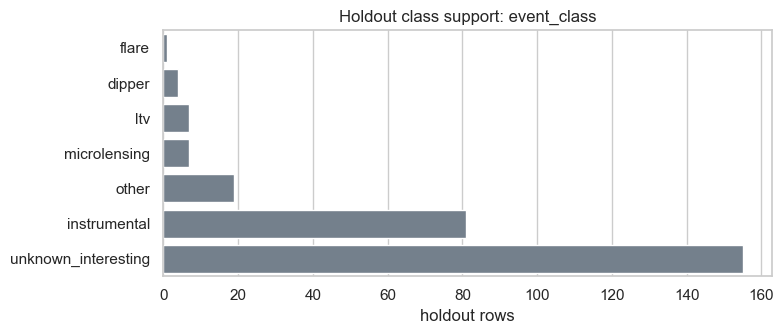

In [6]:
for target, result in results.items():
    display(Markdown(f"### {target}"))
    if not result.cv_metrics.empty:
        metrics = [c for c in ["accuracy", "macro_f1", "weighted_f1"] if c in result.cv_metrics.columns]
        cv_long = result.cv_metrics.melt(id_vars=["fold", "n_eval"], value_vars=metrics, var_name="metric", value_name="value")
        fig, ax = plt.subplots(figsize=(8, 4.2))
        sns.lineplot(data=cv_long, x="fold", y="value", hue="metric", marker="o", ax=ax)
        ax.set_ylim(0, 1)
        ax.set_title(f"Cross-validation metrics: {target}")
        ax.set_ylabel("score")
        fig.tight_layout()
        plt.show()

    report = result.holdout_metrics.get("classification_report", {})
    report_df = pd.DataFrame(report).T if report else pd.DataFrame()
    class_rows = [label for label in result.label_classes if label in report_df.index]
    metric_cols = [c for c in ["precision", "recall", "f1-score"] if c in report_df.columns]
    if class_rows and metric_cols:
        class_metrics = report_df.loc[class_rows, metric_cols].astype(float)
        fig, ax = plt.subplots(figsize=(7.5, max(3.5, 0.45 * len(class_rows))))
        sns.heatmap(class_metrics, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, ax=ax)
        ax.set_title(f"Holdout per-class metrics: {target}")
        fig.tight_layout()
        plt.show()

        support = report_df.loc[class_rows, "support"].astype(float).sort_values(ascending=True)
        fig, ax = plt.subplots(figsize=(8, max(3.5, 0.45 * len(support))))
        sns.barplot(x=support.values, y=support.index, ax=ax, color="slategray")
        ax.set_title(f"Holdout class support: {target}")
        ax.set_xlabel("holdout rows")
        ax.set_ylabel("")
        fig.tight_layout()
        plt.show()


## Feature Importance

In [7]:
feature_importance_tables = {}
for target, result in results.items():
    booster = result.model.booster_
    importance = pd.DataFrame(
        {
            "feature": result.feature_columns,
            "gain": booster.feature_importance(importance_type="gain"),
            "split": booster.feature_importance(importance_type="split"),
        }
    ).sort_values("gain", ascending=False)
    feature_importance_tables[target] = importance
    print()
    print(target)
    display(importance.head(30))



event_class


,feature,gain,split
25,dip_best_amp,3842.558310,501
117,vetting_likely_known,2553.557553,345
23,dip_best_width_param,2086.967704,330
222,stats_gskew,1515.489256,704
281,lc_mag_mad,1404.057721,290
57,jump_max_run_points,1379.260936,204
76,jumper_score,1331.359403,397
43,jump_best_morph,1262.227837,63
50,jump_best_p,1180.586030,402
210,stats_variability_lomb_scargle_best_period_days,1050.612853,624


## Feature Importance Plots

`gain` is the total loss reduction attributed to a feature; `split` is how often LightGBM used it. A feature with high gain but moderate split may be decisive in a few places, while high split can indicate repeated small refinements.

### event_class

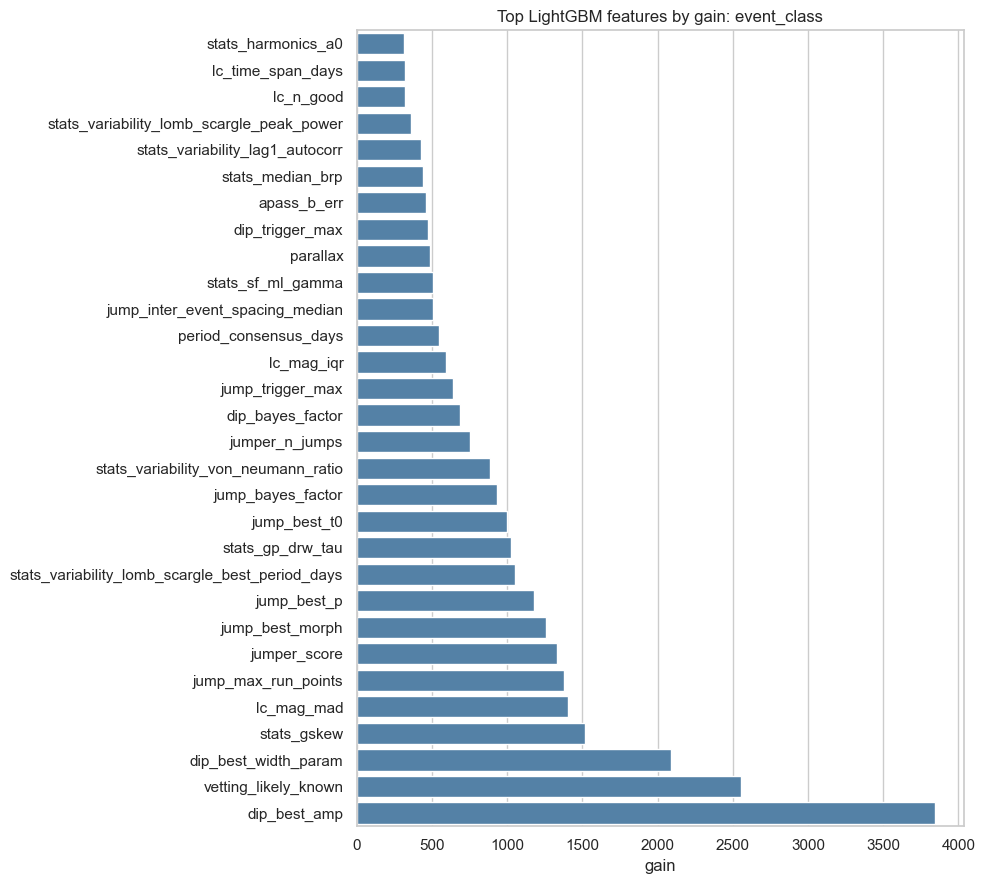

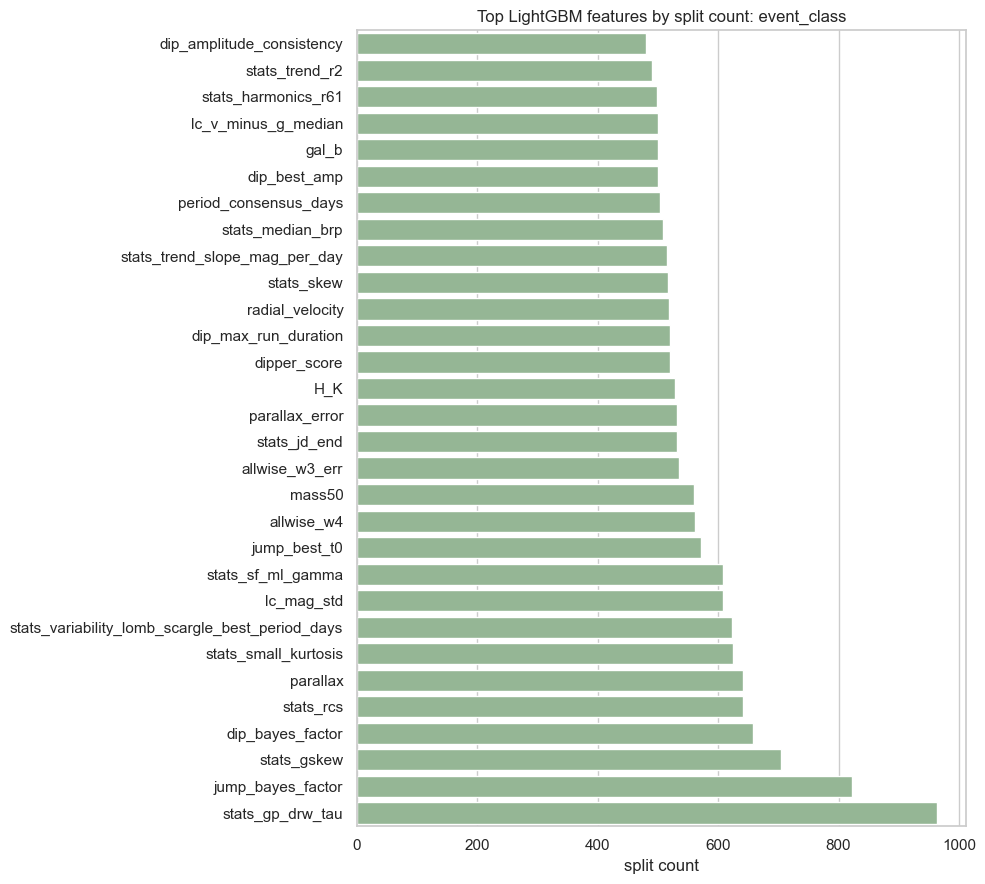

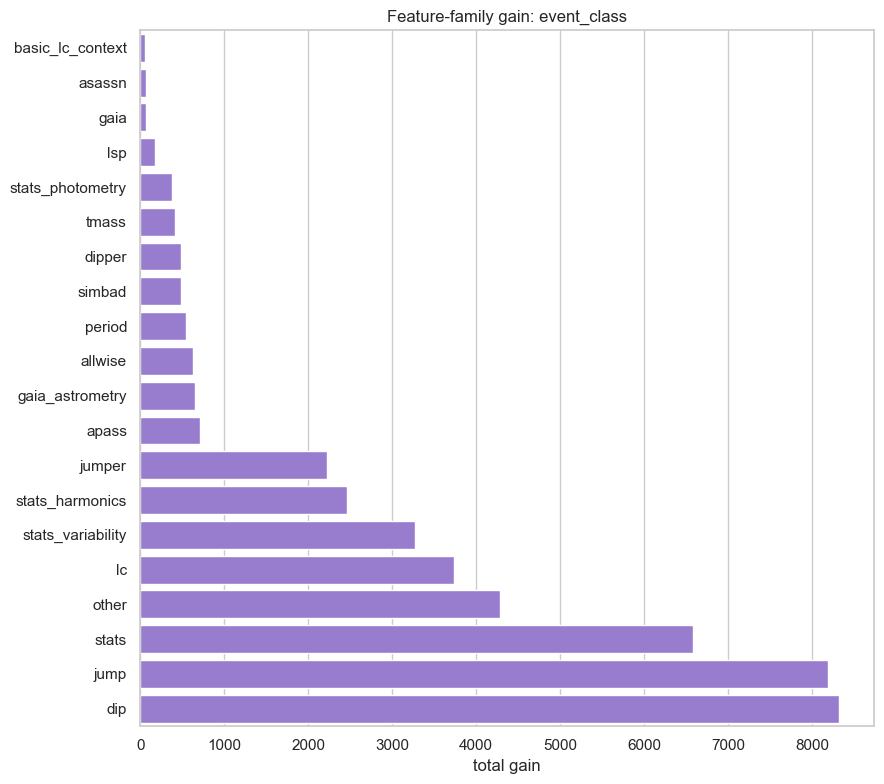

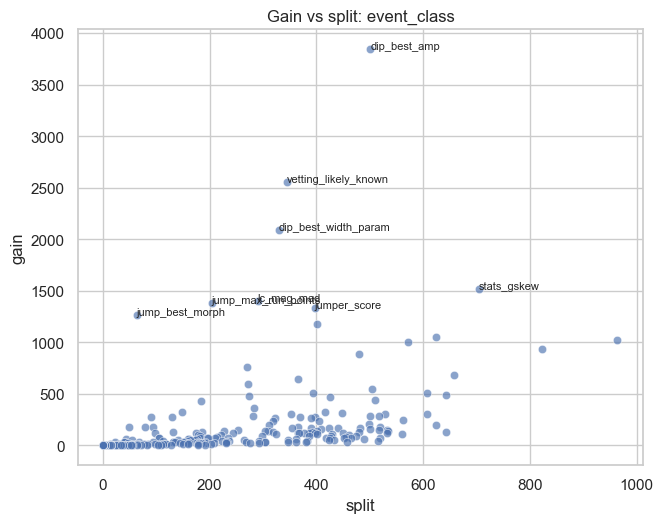

In [8]:
def feature_family(name: str) -> str:
    prefixes = [
        "dip_", "dipper_", "jump_", "jumper_", "microlens_", "period_", "phase_", "lsp_", "pdm_", "ce_",
        "stats_variability_", "stats_photometry_", "stats_harmonics_", "stats_error_", "stats_", "lc_",
        "ltv_", "gaia_", "ztf_", "tns_", "alerce_", "asassn_", "simbad_", "apass_", "tmass_", "unwise_", "allwise_",
    ]
    for prefix in prefixes:
        if name.startswith(prefix):
            return prefix.rstrip("_")
    if name in {"ruwe", "parallax", "parallax_error", "pmra", "pmdec", "pm_total"}:
        return "gaia_astrometry"
    if name in {"baseline_mag", "n_points", "n_cameras", "cadence_median_days"}:
        return "basic_lc_context"
    return "other"

for target, importance in feature_importance_tables.items():
    display(Markdown(f"### {target}"))
    top_gain = importance.head(30).sort_values("gain", ascending=True)
    fig, ax = plt.subplots(figsize=(10, 9))
    sns.barplot(data=top_gain, y="feature", x="gain", ax=ax, color="steelblue")
    ax.set_title(f"Top LightGBM features by gain: {target}")
    ax.set_xlabel("gain")
    ax.set_ylabel("")
    fig.tight_layout()
    plt.show()

    top_split = importance.sort_values("split", ascending=False).head(30).sort_values("split", ascending=True)
    fig, ax = plt.subplots(figsize=(10, 9))
    sns.barplot(data=top_split, y="feature", x="split", ax=ax, color="darkseagreen")
    ax.set_title(f"Top LightGBM features by split count: {target}")
    ax.set_xlabel("split count")
    ax.set_ylabel("")
    fig.tight_layout()
    plt.show()

    fam = importance.copy()
    fam["family"] = fam["feature"].map(feature_family)
    fam_summary = fam.groupby("family", as_index=False).agg(gain=("gain", "sum"), split=("split", "sum"))
    fam_summary = fam_summary.sort_values("gain", ascending=False).head(20).sort_values("gain", ascending=True)
    fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * len(fam_summary))))
    sns.barplot(data=fam_summary, y="family", x="gain", ax=ax, color="mediumpurple")
    ax.set_title(f"Feature-family gain: {target}")
    ax.set_xlabel("total gain")
    ax.set_ylabel("")
    fig.tight_layout()
    plt.show()

    nonzero = importance.loc[(importance["gain"] > 0) | (importance["split"] > 0)].copy()
    if not nonzero.empty:
        fig, ax = plt.subplots(figsize=(6.8, 5.4))
        sns.scatterplot(data=nonzero, x="split", y="gain", ax=ax, alpha=0.65)
        for _, row in nonzero.sort_values("gain", ascending=False).head(8).iterrows():
            ax.text(row["split"], row["gain"], row["feature"], fontsize=8)
        ax.set_title(f"Gain vs split: {target}")
        fig.tight_layout()
        plt.show()
